In [1]:
# Cell 1 - Imports & global settings
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Ensure output directories exist before any savefig call
os.makedirs("../results", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("All imports OK")

All imports OK


In [2]:
# Cell 2 - Load raw data
df = pd.read_csv(
    "../data/raw/AirQualityUCI.csv",
    sep=";", # semicolon-delimited, not comma
    usecols=range(15) # columns 15 and 16 are empty artefacts – exclude them
)

print(f"Shape (raw): {df.shape}")
print(f"\nColumn names: \n{df.columns.tolist()}")
print(f"\nFirst 3 rows: ")
df.head(3)

Shape (raw): (9471, 15)

Column names: 
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

First 3 rows: 


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"


In [3]:
# Cell 3 - Drop empty rows, fix types, parse datetime index

# 1. Drop entirely-null rows (113 trailing blank rows)
df.dropna(how="all", inplace=True)
print(f"Shape after dropping empty rows: {df.shape}") 

# 2. Fix the European decimal format
euro_cols = ["CO(GT)", "C6H6(GT)", "T", "RH", "AH"]
# These 5 columns use a comma as a decimal separator -> pandas reads them as objects.
# Must fix before any numeric operation or silently compute on strings
for col in euro_cols:
    df[col] = df[col].astype(str).str.replace(",", ".").astype(float)

# 3. Build a proper DatetimeIndex
# Date and Time are separate string columns – merge and parse into one index
# Format: day/month/year hour.minute.second (e.g. 10/03/2004 18.00.00)
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S"
)
df.set_index("Datetime", inplace=True)
df.drop(columns=["Date", "Time"], inplace=True)
df.sort_index(inplace=True)

print(f"Date range: {df.index.min()} --> {df.index.max()}")
print(f"Total hourly records: {len(df)}")
print(f"\nDtypes after fix: \n{df.dtypes}")

Shape after dropping empty rows: (9357, 15)
Date range: 2004-03-10 18:00:00 --> 2005-04-04 14:00:00
Total hourly records: 9357

Dtypes after fix: 
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


In [4]:
# Cell 4 - Replace sentinel -200 with NaN and audit missing values

# 1. Replace sentinel
# -200 is the dataset's encoding for "no reading available" (UCI documentation)
# Leaving it in corrupts every statistic, correlation, and model prediction
df.replace(-200, np.nan, inplace=True)

# 2. Audit missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values("Missing %", ascending=False)

print(f"Missing value report (all columns): ")
print(missing_report.to_string())

Missing value report (all columns): 
               Missing Count  Missing %
NMHC(GT)                8443      90.23
CO(GT)                  1683      17.99
NO2(GT)                 1642      17.55
NOx(GT)                 1639      17.52
PT08.S1(CO)              366       3.91
C6H6(GT)                 366       3.91
PT08.S2(NMHC)            366       3.91
PT08.S3(NOx)             366       3.91
PT08.S4(NO2)             366       3.91
PT08.S5(O3)              366       3.91
T                        366       3.91
RH                       366       3.91
AH                       366       3.91


In [5]:
# Cell 5 - Drop NMHC(GT)

# 90.23% missing — cannot be imputed at this rate.
# Retaining it would introduce more noise than signal into any model.
df.drop(columns=["NMHC(GT)"], inplace=True)

print(f"Shape after droping NMHC(GT): {df.shape}")
print(f"\nRemaining columns ({len(df.columns)}):")
for col in df.columns:
    print(f"   {col}")

Shape after droping NMHC(GT): (9357, 12)

Remaining columns (12):
   CO(GT)
   PT08.S1(CO)
   C6H6(GT)
   PT08.S2(NMHC)
   NOx(GT)
   PT08.S3(NOx)
   NO2(GT)
   PT08.S4(NO2)
   PT08.S5(O3)
   T
   RH
   AH


In [6]:
# Cell 6 – Descriptive statistics
# Now that -200 is replaced with NaN, these numbers are meaningful.
# Before the fix, mean CO appeared negative – a physical impossibility

stats = df.describe().T.round(2)
stats["missing %"] = (df.isnull().sum() / len(df) * 100).round(2)
stats

,count,mean,std,min,25%,50%,75%,max,missing %
CO(GT),7674.0,2.15,1.45,0.10,1.10,1.8,2.90,11.90,17.99
PT08.S1(CO),8991.0,1099.83,217.08,647.00,937.00,1063.0,1231.00,2040.00,3.91
C6H6(GT),8991.0,10.08,7.45,0.10,4.40,8.2,14.00,63.70,3.91
PT08.S2(NMHC),8991.0,939.15,266.83,383.00,734.50,909.0,1116.00,2214.00,3.91
NOx(GT),7718.0,246.90,212.98,2.00,98.00,180.0,326.00,1479.00,17.52
PT08.S3(NOx),8991.0,835.49,256.82,322.00,658.00,806.0,969.50,2683.00,3.91
NO2(GT),7715.0,113.09,48.37,2.00,78.00,109.0,142.00,340.00,17.55
PT08.S4(NO2),8991.0,1456.26,346.21,551.00,1227.00,1463.0,1674.00,2775.00,3.91
PT08.S5(O3),8991.0,1022.91,398.48,221.00,731.50,963.0,1273.50,2523.00,3.91
T,8991.0,18.32,8.83,-1.90,11.80,17.8,24.40,44.60,3.91


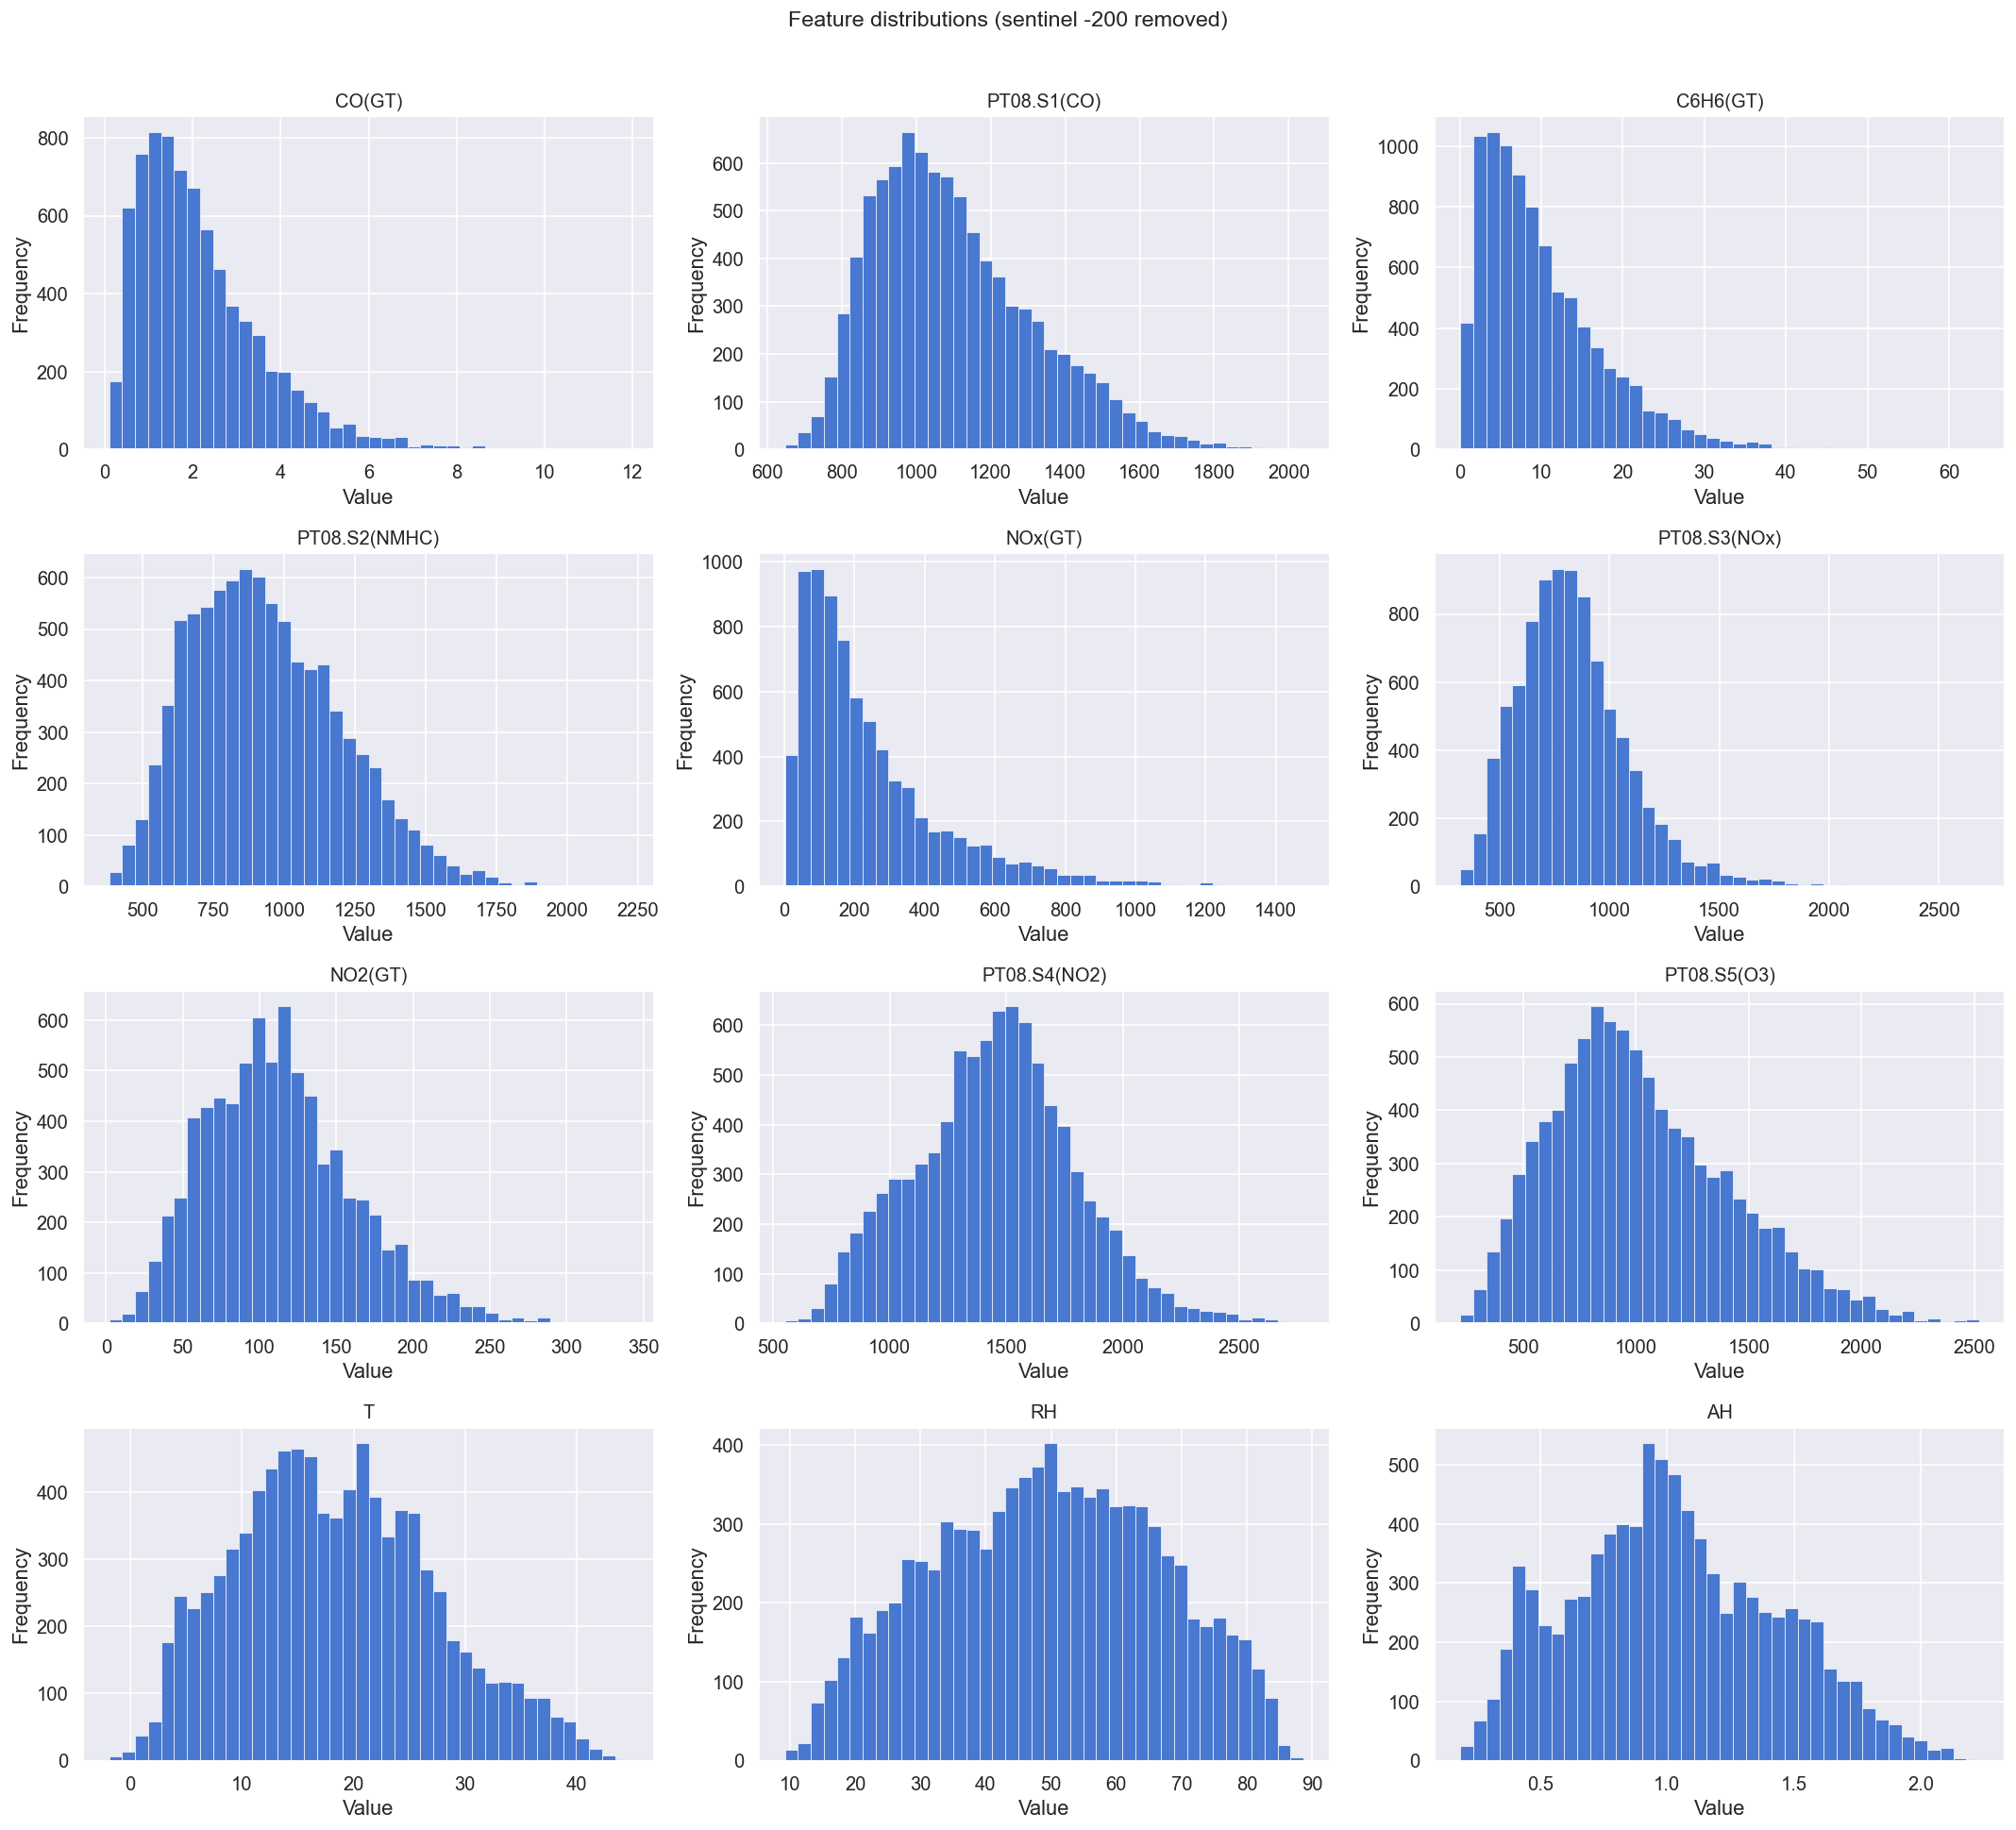

Saved --> results/distributions.png


In [7]:
# Cell 7 – Feature distributions
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fix, axes = plt.subplots(
    nrows=4, ncols=3,
    figsize=(18, 16)
)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, edgecolor="white", linewidth=0.4)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Feature distributions (sentinel -200 removed)",
    y=1.01, fontsize=14
)
plt.tight_layout()
plt.savefig("../results/distributions.png", bbox_inches="tight")
plt.show()
print("Saved --> results/distributions.png")

In [12]:
corr = df[numeric_cols].corr()
print(corr)

                 CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)   NOx(GT)  \
CO(GT)         1.000000     0.879288  0.931078       0.915514  0.795028   
PT08.S1(CO)    0.879288     1.000000  0.883795       0.892964  0.713654   
C6H6(GT)       0.931078     0.883795  1.000000       0.981950  0.718839   
PT08.S2(NMHC)  0.915514     0.892964  0.981950       1.000000  0.704435   
NOx(GT)        0.795028     0.713654  0.718839       0.704435  1.000000   
PT08.S3(NOx)  -0.703446    -0.771938 -0.735744      -0.796703 -0.655707   
NO2(GT)        0.683343     0.641529  0.614474       0.646245  0.763111   
PT08.S4(NO2)   0.630703     0.682881  0.765731       0.777254  0.233731   
PT08.S5(O3)    0.854182     0.899324  0.865689       0.880578  0.787046   
T              0.022109     0.048627  0.198956       0.241373 -0.269683   
RH             0.048890     0.114606 -0.061681      -0.090380  0.221032   
AH             0.048556     0.135324  0.167972       0.186933 -0.149323   

               PT08.S3(N

Saved --> results/correlation_heatmap.png


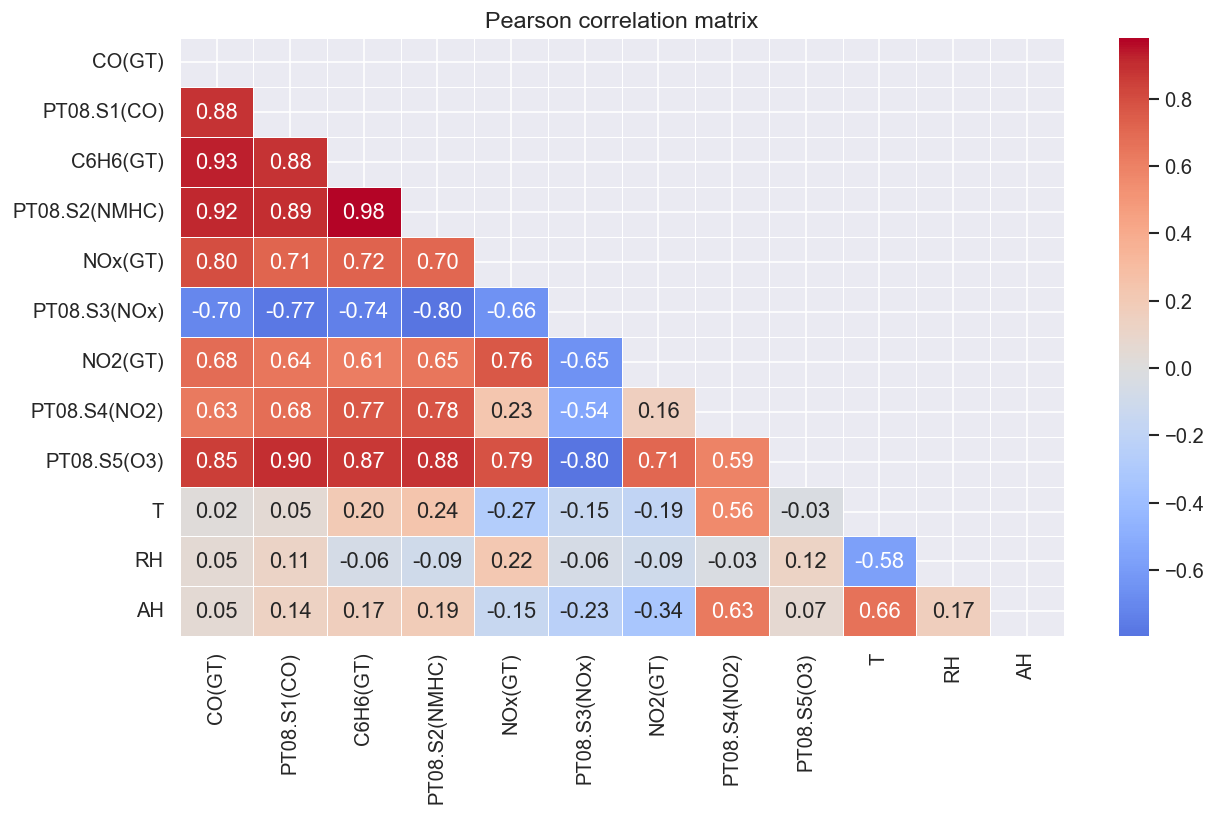

In [23]:
# Cell 8 – Correlation heatmap
corr = df[numeric_cols].corr()

# Mask upper triangle – redundant mirror of lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Pearson correlation matrix", fontsize=14)
plt.tight_layout()
plt.savefig("../results/correlation_heatmap.png", bbox_inches="tight")
print("Saved --> results/correlation_heatmap.png")

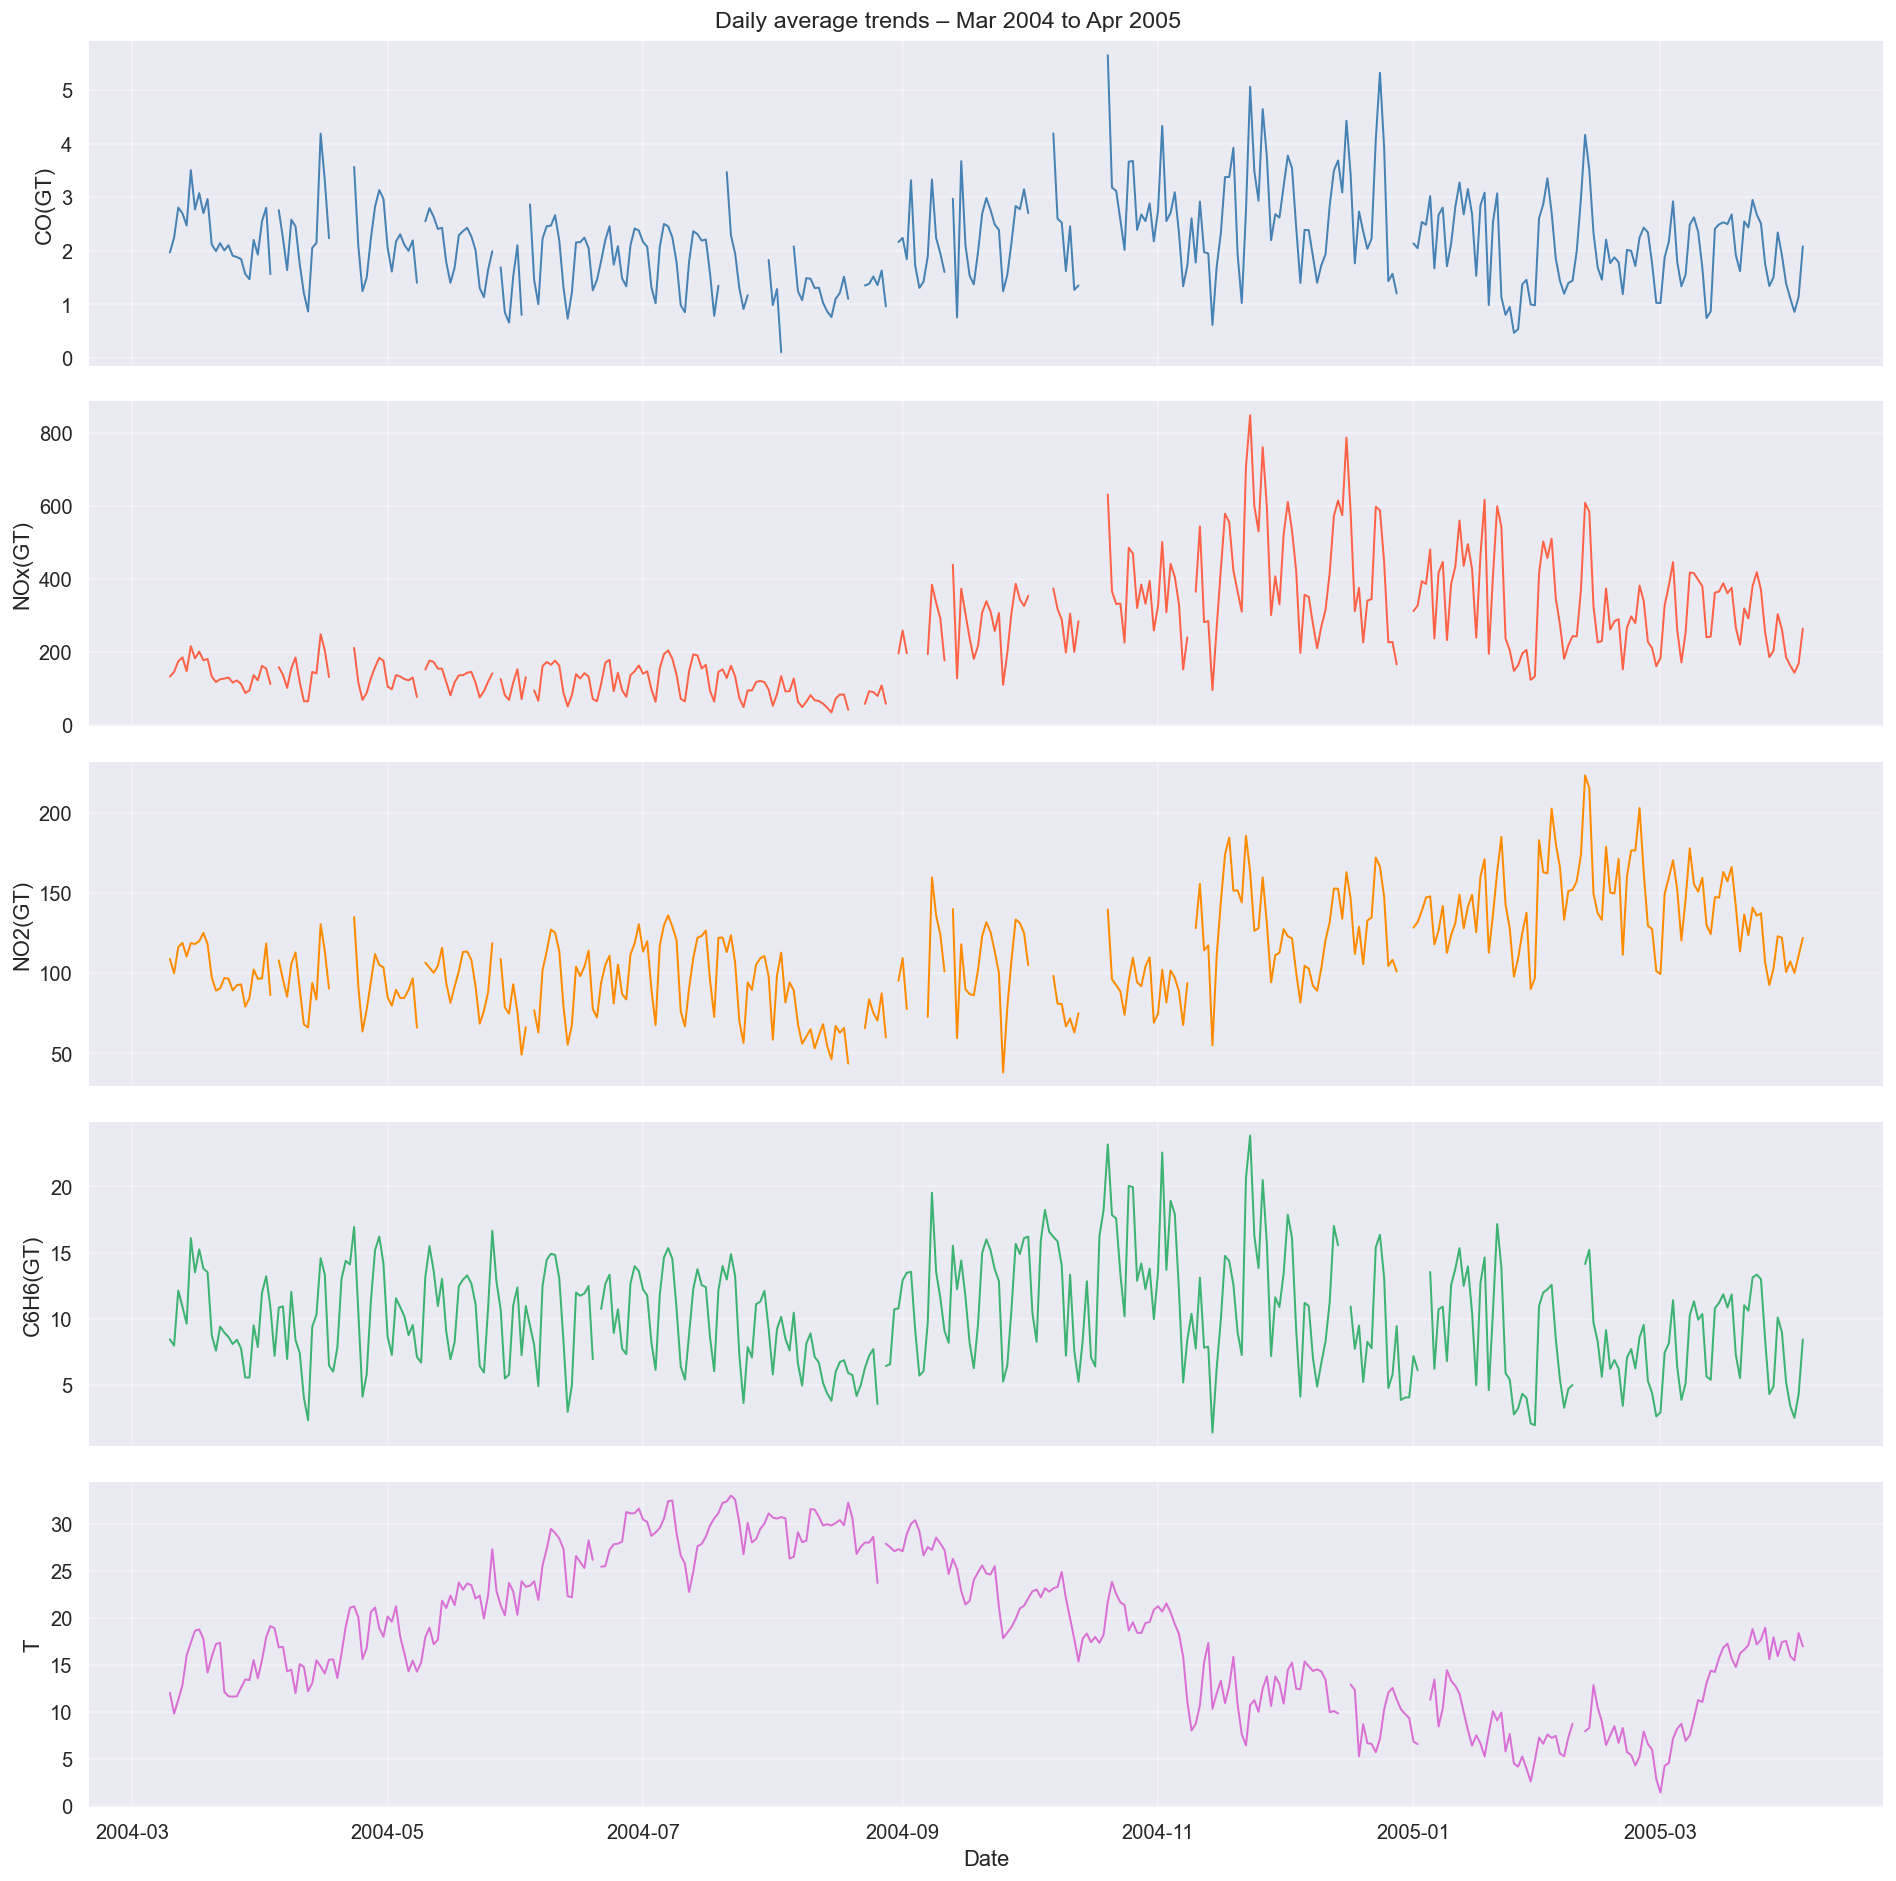

Saved --> results/temporal_trends.png


In [25]:
# Cell 9 - Daily average temporal trends
daily = df[["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)", "T"]].resample("D").mean()

fig, axes = plt.subplots(5, 1, figsize=(16, 16), sharex=True)
plot_cols = ["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)", "T"]
colors = ["steelblue", "tomato", "darkorange", "mediumseagreen", "orchid"]

for ax, col, color in zip(axes, plot_cols, colors):
    ax.plot(daily.index, daily[col], color=color, linewidth=1.2)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("Date")
plt.suptitle("Daily average trends – Mar 2004 to Apr 2005", fontsize=14)
plt.tight_layout()
plt.savefig("../results/temporal_trends.png", bbox_inches="tight")
plt.show()
print("Saved --> results/temporal_trends.png")

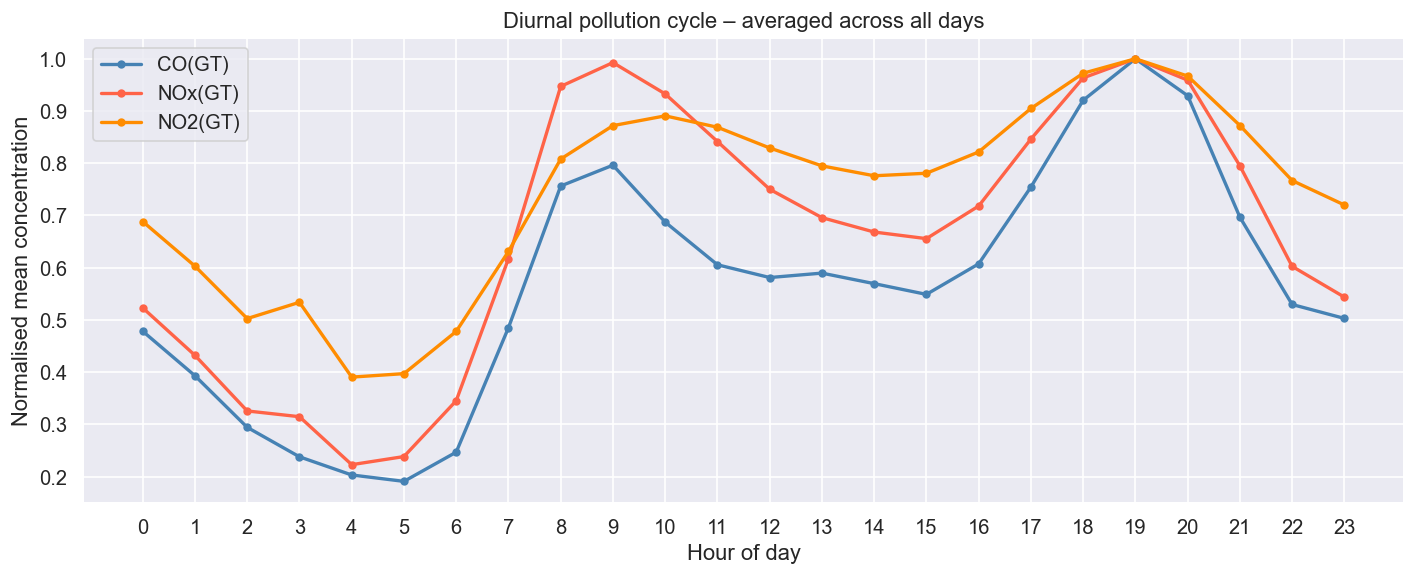

Saved --> results/diurnal_cycle.png


In [28]:
# Cell 10 - Diurnal cycle (hourly patterns averaged across all days)
hourly_avg = df[["CO(GT)", "NOx(GT)", "NO2(GT)"]].groupby(df.index.hour).mean()

fix, ax = plt.subplots(figsize=(12, 5))
for col, color in zip(
    ["CO(GT)", "NOx(GT)", "NO2(GT)"],
    ["steelblue", "tomato", "darkorange"]
):
    normalized = hourly_avg[col] / hourly_avg[col].max()
    ax.plot(
        hourly_avg.index, normalized,
        label=col, linewidth=2,
        marker="o", markersize=4,
        color=color
    )

ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Normalised mean concentration")
ax.set_title("Diurnal pollution cycle – averaged across all days")
ax.legend()
plt.tight_layout()
plt.savefig("../results/diurnal_cycle.png", bbox_inches="tight")
plt.show()
print("Saved --> results/diurnal_cycle.png")

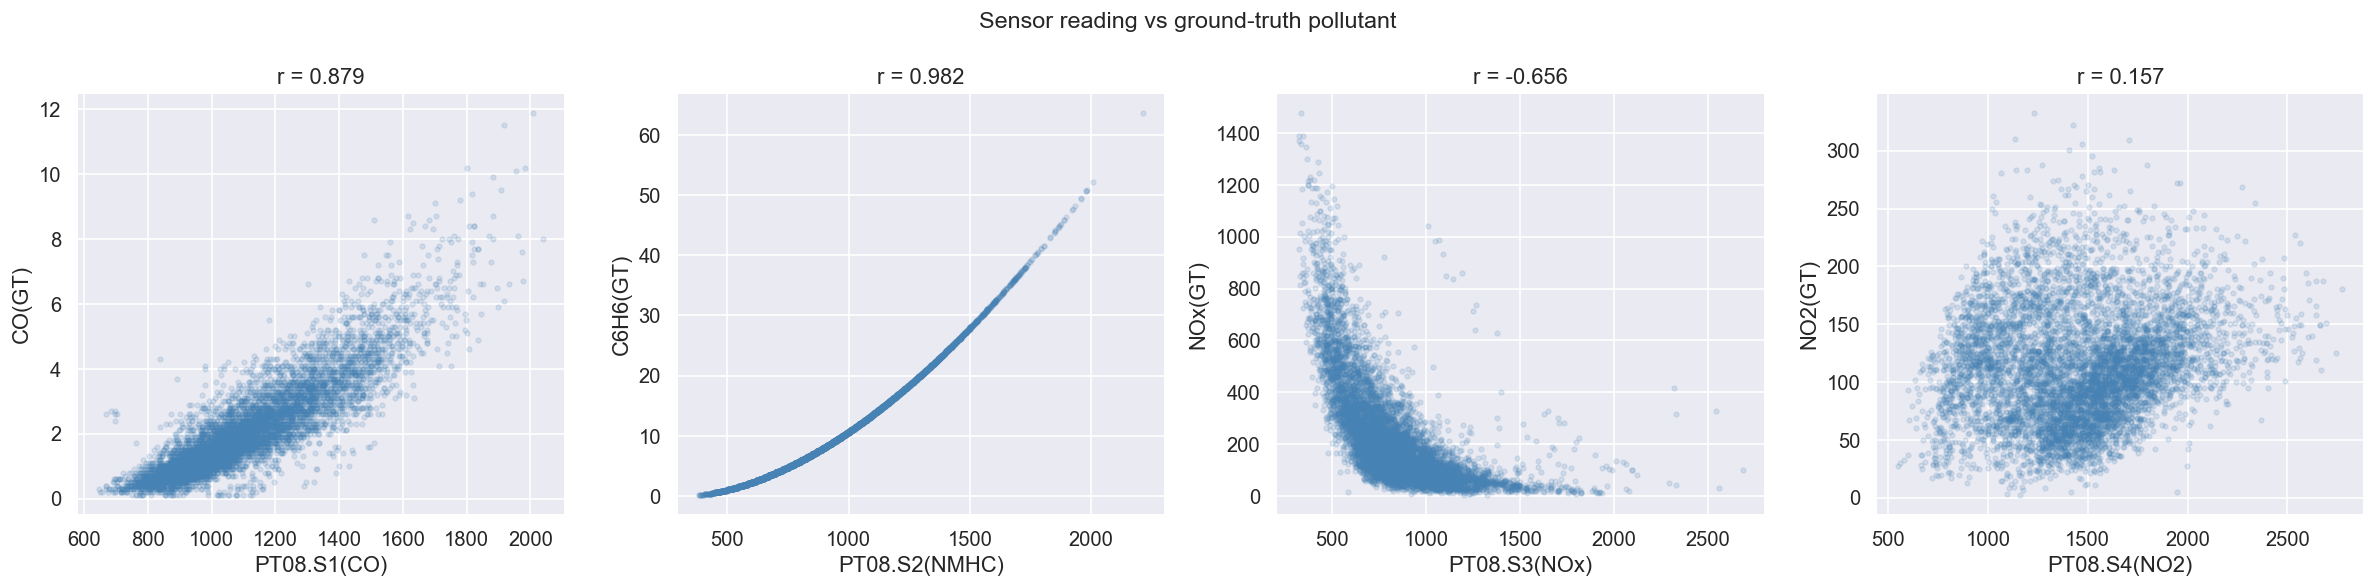

Saved → results/sensor_vs_gt.png


In [31]:
# Cell 11 — Sensor vs ground-truth scatter plots
# Validates that metal-oxide sensors track real pollutant concentrations.
# Non-linearity here informs whether sensor readings need transformation.
pairs = [
    ("PT08.S1(CO)",   "CO(GT)"),
    ("PT08.S2(NMHC)", "C6H6(GT)"),
    ("PT08.S3(NOx)",  "NOx(GT)"),
    ("PT08.S4(NO2)",  "NO2(GT)"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (sensor, gt) in zip(axes, pairs):
    subset = df[[sensor, gt]].dropna()
    ax.scatter(
        subset[sensor], subset[gt],
        alpha=0.15, s=8, color="steelblue"
    )
    ax.set_xlabel(sensor)
    ax.set_ylabel(gt)
    r = subset.corr().iloc[0, 1]
    ax.set_title(f"r = {r:.3f}")

plt.suptitle("Sensor reading vs ground-truth pollutant", fontsize=14)
plt.tight_layout()
plt.savefig("../results/sensor_vs_gt.png", bbox_inches="tight")
plt.show()
print("Saved → results/sensor_vs_gt.png")

In [33]:
# Cell 12 - Save cleaned DataFrame for preprocessing pipeline
df.to_csv("../data/processed/AirQualityUCI_cleaned.csv")

# Verify the file was written correctly
saved = pd.read_csv(
    "../data/processed/AirQualityUCI_cleaned.csv",
    index_col="Datetime",
    parse_dates=True
)

print(f"Saved shape: \t{saved.shape}")
print(f"Loaded shape: \t{saved.shape}")
print(f"Columns: {saved.columns.tolist()}")
print(f"Date range: {saved.index.min()} --> {saved.index.max()}")
print(f"Missing values remaining: \n{saved.isnull().sum()}")

Saved shape: 	(9357, 12)
Loaded shape: 	(9357, 12)
Columns: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Date range: 2004-03-10 18:00:00 --> 2005-04-04 14:00:00
Missing values remaining: 
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64
